# **Machine Learning on Big Data (CN7030) CRWK 23-24 Term B [60% weighting]**
# **Group ID: 3**
1.   Student 1: Kruttika Jamalpuram & u2434023
2.   Student 2: Aishwarya Nitin Sonar & u2479461
3.   Student 3: Purvi Dawda & u2601770

**Dataset:** UK Road Accident

**Size:** 500 MB

The project utilizes the UK Accident Dataset, a comprehensive dataset containing detailed information on road accidents in the United Kingdom.

This Dataset contains 33 Features covering over a 1.8 million records. This dataset consists of various features like:
Accidental / Longitude, Accident_Severity, Number_of_Vehicles, Number_of_Casualties, Light_Conditions, Weather_Conditions, Road_Surface_Conditions, Year.

Our main aim on this dataset is to predict the severity of the accident.


# **Initiate and Configure Spark**

The command !pip install pyspark is used to install the PySpark package using the pip package manager in Python. Installing PySpark using pip allows you to use Spark's functionality in your Python environment

In [2]:
!pip install pyspark


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=7ca16c0437175351fd87bde4a91f8a677c1fdf14e735af8e303481eaa775e813
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


Setting up a sparksession, the primary interface for handling structured data in Pyspark, and setting it up to run locally, using the maximum number of worker threads available on the system's logical cores.

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

Creating a sparksession. Builder object that is used to configure and build the sparksession.
Set the spark application name to "UKAccidents".
The application name is used to identify the application on the cluster and in the spark web interface.
.config("spark.some.config.option", "some-value"): this specifies a specific configuration option for the spark program.
In this case, it sets the option "spark.some.config.option" to the value "some-value". By chaining additional .config() calls, we can set multiple configuration options.
getorcreate(): this method checks to see if a sparksession instance exists.
If it does, it returns the current instance; otherwise, it creates a new one based on the builder's configuration.

In [4]:
spark = SparkSession \
    .builder \
    .appName("UKAccidents") \
    .config("spark.some.config.option", "some-value") \
    .config("spark.driver.memory", "8g").config("spark.executor.memory", "8g").getOrCreate()

**Mounting the drive**

In [5]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# **Task 1 - Data Loading and Preprocessing (15 marks)**
---

**Student 1: Kruttika Jamalpuram**

**Data Loading, creating a dataframe and removing null values**

**Data Loading**

In [6]:
filepath = '/content/drive/MyDrive/RoadAccidents/UK_Accident.csv'

roadAccident_df = spark.read.csv(filepath, header=True, inferSchema=True)

roadAccident_df.head()

Row(_c0=0, Accident_Index='200501BS00001', Location_Easting_OSGR=525680.0, Location_Northing_OSGR=178240.0, Longitude=-0.19117, Latitude=51.489096, Police_Force=1, Accident_Severity=2, Number_of_Vehicles=1, Number_of_Casualties=1, Date='04/01/2005', Day_of_Week=3, Time=datetime.datetime(2024, 5, 4, 17, 42), Local_Authority_(District)=12, Local_Authority_(Highway)='E09000020', 1st_Road_Class=3, 1st_Road_Number=3218, Road_Type='Single carriageway', Speed_limit=30, Junction_Control='None', 2nd_Road_Class=-1, 2nd_Road_Number=0, Pedestrian_Crossing-Human_Control='None within 50 metres', Pedestrian_Crossing-Physical_Facilities='Zebra crossing', Light_Conditions='Daylight: Street light present', Weather_Conditions='Raining without high winds', Road_Surface_Conditions='Wet/Damp', Special_Conditions_at_Site='None', Carriageway_Hazards='None', Urban_or_Rural_Area=1, Did_Police_Officer_Attend_Scene_of_Accident='Yes', LSOA_of_Accident_Location='E01002849', Year=2005)

In [7]:
roadAccident_df.show()

+---+--------------+---------------------+----------------------+---------+---------+------------+-----------------+------------------+--------------------+----------+-----------+-------------------+--------------------------+-------------------------+--------------+---------------+------------------+-----------+--------------------+--------------+---------------+---------------------------------+---------------------------------------+--------------------+--------------------+-----------------------+--------------------------+-------------------+-------------------+-------------------------------------------+-------------------------+----+
|_c0|Accident_Index|Location_Easting_OSGR|Location_Northing_OSGR|Longitude| Latitude|Police_Force|Accident_Severity|Number_of_Vehicles|Number_of_Casualties|      Date|Day_of_Week|               Time|Local_Authority_(District)|Local_Authority_(Highway)|1st_Road_Class|1st_Road_Number|         Road_Type|Speed_limit|    Junction_Control|2nd_Road_Class|2

Returns a list of all column names in the PySpark DataFrame accident_df

In [8]:
roadAccident_df.columns

['_c0',
 'Accident_Index',
 'Location_Easting_OSGR',
 'Location_Northing_OSGR',
 'Longitude',
 'Latitude',
 'Police_Force',
 'Accident_Severity',
 'Number_of_Vehicles',
 'Number_of_Casualties',
 'Date',
 'Day_of_Week',
 'Time',
 'Local_Authority_(District)',
 'Local_Authority_(Highway)',
 '1st_Road_Class',
 '1st_Road_Number',
 'Road_Type',
 'Speed_limit',
 'Junction_Control',
 '2nd_Road_Class',
 '2nd_Road_Number',
 'Pedestrian_Crossing-Human_Control',
 'Pedestrian_Crossing-Physical_Facilities',
 'Light_Conditions',
 'Weather_Conditions',
 'Road_Surface_Conditions',
 'Special_Conditions_at_Site',
 'Carriageway_Hazards',
 'Urban_or_Rural_Area',
 'Did_Police_Officer_Attend_Scene_of_Accident',
 'LSOA_of_Accident_Location',
 'Year']

Dropping the columns that are not necessary for feature selection

In [9]:
columns_to_drop = ['Unnamed: 0', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Local_Authority_(Highway)', 'LSOA_of_Accident_Location']
roadAccident_df = roadAccident_df.drop(*columns_to_drop)

In [10]:
roadAccident_df.show(5)

+---+--------------+---------+---------+------------+-----------------+------------------+--------------------+----------+-----------+-------------------+--------------------------+--------------+---------------+------------------+-----------+--------------------+--------------+---------------+---------------------------------+---------------------------------------+--------------------+--------------------+-----------------------+--------------------------+-------------------+-------------------+-------------------------------------------+----+
|_c0|Accident_Index|Longitude| Latitude|Police_Force|Accident_Severity|Number_of_Vehicles|Number_of_Casualties|      Date|Day_of_Week|               Time|Local_Authority_(District)|1st_Road_Class|1st_Road_Number|         Road_Type|Speed_limit|    Junction_Control|2nd_Road_Class|2nd_Road_Number|Pedestrian_Crossing-Human_Control|Pedestrian_Crossing-Physical_Facilities|    Light_Conditions|  Weather_Conditions|Road_Surface_Conditions|Special_Condi

**Data Cleaning:** Data cleaning is the process of identifying and correcting errors, inconsistencies, and missing values in data to improve its quality and accuracy. It is an essential step in the data preparation process to ensure that the data is ready for analysis or further processing

Getting the count of the number of rows and columns

In [11]:
# Getting the count of number of rows
no_of_rows = roadAccident_df.count()

# Getting the count of number of columns
no_of_columns = len(roadAccident_df.columns)

# Printing the number of rows and columns
print("No. of rows: {}".format(no_of_rows))
print("No. of cols: {}".format(no_of_columns))

No. of rows: 1504150
No. of cols: 29


Printing the column names, their datatype and non-null count for understanding the data

In [12]:
from pyspark.sql.functions import col

# Calculating the count of non-null values for each column in the dataset
non_null_valueCount = [roadAccident_df.where(col(c).isNotNull()).count() for c in roadAccident_df.columns]

# Getting the data types of each column in teh dataset
acc_dataType = [str(field.dataType) for field in roadAccident_df.schema.fields]

# Getting the names of the columns in the accident dataset
acc_column_names = roadAccident_df.columns

# Displaying the information
for i in range(len(acc_column_names)):
    print("Column '{}': DataType={}, Non-Null Count={}".format(acc_column_names[i], acc_dataType[i], non_null_valueCount[i]))

Column '_c0': DataType=IntegerType(), Non-Null Count=1504150
Column 'Accident_Index': DataType=StringType(), Non-Null Count=1504150
Column 'Longitude': DataType=DoubleType(), Non-Null Count=1504049
Column 'Latitude': DataType=DoubleType(), Non-Null Count=1504150
Column 'Police_Force': DataType=IntegerType(), Non-Null Count=1504150
Column 'Accident_Severity': DataType=IntegerType(), Non-Null Count=1504150
Column 'Number_of_Vehicles': DataType=IntegerType(), Non-Null Count=1504150
Column 'Number_of_Casualties': DataType=IntegerType(), Non-Null Count=1504150
Column 'Date': DataType=StringType(), Non-Null Count=1504150
Column 'Day_of_Week': DataType=IntegerType(), Non-Null Count=1504150
Column 'Time': DataType=TimestampType(), Non-Null Count=1504033
Column 'Local_Authority_(District)': DataType=IntegerType(), Non-Null Count=1504150
Column '1st_Road_Class': DataType=IntegerType(), Non-Null Count=1504150
Column '1st_Road_Number': DataType=IntegerType(), Non-Null Count=1504150
Column 'Road_Ty

Printing the column names with the null values to perform data cleaning

In [13]:
from pyspark.sql.functions import col

# Checking for null values in each column in the dataset
acc_null_columns = [c for c in roadAccident_df.columns if roadAccident_df.where(col(c).isNull()).count() > 0]

# Validating if any columns have null values
if acc_null_columns:
    print("Columns with null values:", acc_null_columns)
    print("There are null values in the DataFrame.")
else:
    print("There are no null values in the DataFrame.")

Columns with null values: ['Longitude', 'Time', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities']
There are null values in the DataFrame.


Print the percentage of null values in each column

In [14]:
from pyspark.sql.functions import col, format_number

# Calculating the percentage of null values in each column
acc_null_percentage = [(roadAccident_df.where(col(c).isNull()).count() / roadAccident_df.count()) * 100 for c in roadAccident_df.columns]

# Creating a dictionary with column names and their respective null percentages
acc_nullPercent_dict = dict(zip(roadAccident_df.columns, acc_null_percentage))

# Printing the null percentages for each column in the dataset
for item, nullPercentage in acc_nullPercent_dict.items():
  print("Column '{}': {:.4f}% null values".format(item, nullPercentage))

Column '_c0': 0.0000% null values
Column 'Accident_Index': 0.0000% null values
Column 'Longitude': 0.0067% null values
Column 'Latitude': 0.0000% null values
Column 'Police_Force': 0.0000% null values
Column 'Accident_Severity': 0.0000% null values
Column 'Number_of_Vehicles': 0.0000% null values
Column 'Number_of_Casualties': 0.0000% null values
Column 'Date': 0.0000% null values
Column 'Day_of_Week': 0.0000% null values
Column 'Time': 0.0078% null values
Column 'Local_Authority_(District)': 0.0000% null values
Column '1st_Road_Class': 0.0000% null values
Column '1st_Road_Number': 0.0000% null values
Column 'Road_Type': 0.0000% null values
Column 'Speed_limit': 0.0000% null values
Column 'Junction_Control': 0.0000% null values
Column '2nd_Road_Class': 0.0000% null values
Column '2nd_Road_Number': 0.0000% null values
Column 'Pedestrian_Crossing-Human_Control': 0.0011% null values
Column 'Pedestrian_Crossing-Physical_Facilities': 0.0023% null values
Column 'Light_Conditions': 0.0000% nu

The null values are very less when compared to the number of rows present in the data, hence we can drop the rows with the null values

In [15]:
# Dropping the rows with null values in below columns
drop_columns = ['Longitude', 'Time', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities']
roadAccident_df = roadAccident_df.na.drop(subset=drop_columns)

# Displaying the dataframe after dropping the null values
roadAccident_df.show()

+---+--------------+---------+---------+------------+-----------------+------------------+--------------------+----------+-----------+-------------------+--------------------------+--------------+---------------+------------------+-----------+--------------------+--------------+---------------+---------------------------------+---------------------------------------+--------------------+--------------------+-----------------------+--------------------------+-------------------+-------------------+-------------------------------------------+----+
|_c0|Accident_Index|Longitude| Latitude|Police_Force|Accident_Severity|Number_of_Vehicles|Number_of_Casualties|      Date|Day_of_Week|               Time|Local_Authority_(District)|1st_Road_Class|1st_Road_Number|         Road_Type|Speed_limit|    Junction_Control|2nd_Road_Class|2nd_Road_Number|Pedestrian_Crossing-Human_Control|Pedestrian_Crossing-Physical_Facilities|    Light_Conditions|  Weather_Conditions|Road_Surface_Conditions|Special_Condi

**Visualisation 1: Distribution of Accidents by Day of Week**

In [16]:
from pyspark.sql import functions as F

accident_count = roadAccident_df.groupBy('Day_of_Week').agg(F.count('*').alias('Accident Count')).orderBy('Day_of_Week')
accident_count.show()

+-----------+--------------+
|Day_of_Week|Accident Count|
+-----------+--------------+
|          1|        164942|
|          2|        213715|
|          3|        224080|
|          4|        226307|
|          5|        226366|
|          6|        247098|
|          7|        201382|
+-----------+--------------+



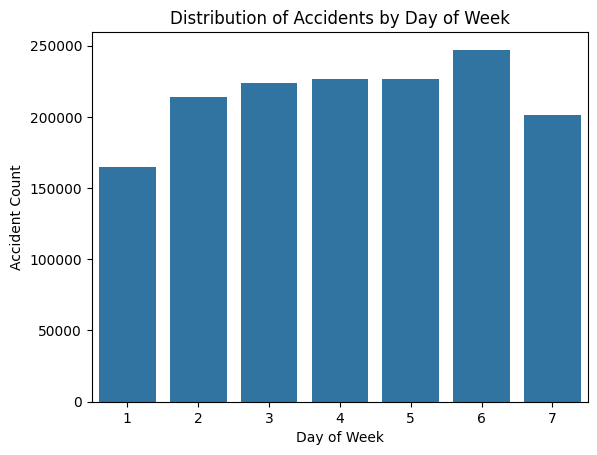

In [17]:
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sns

accident_count_pd = accident_count.toPandas()

# Create a box plot
sns.barplot(x='Day_of_Week', y='Accident Count', data=accident_count_pd)

# Set the plot title and labels
pt.title('Distribution of Accidents by Day of Week')
pt.xlabel('Day of Week')
pt.ylabel('Accident Count')

# Show the plot
pt.show()

**Visualisation 2: Relationship Between Speed Limit and Accident Severity**

In [18]:
from pyspark.sql import functions as F

accident_speed = roadAccident_df.groupBy('Speed_limit', 'Accident_Severity').agg(F.count('*').alias('Accident Count'))
accident_speed.show()


+-----------+-----------------+--------------+
|Speed_limit|Accident_Severity|Accident Count|
+-----------+-----------------+--------------+
|         10|                2|             2|
|         70|                2|         13050|
|         20|                2|          2453|
|         60|                3|        186232|
|         60|                2|         44436|
|         20|                3|         14602|
|         60|                1|          7478|
|         30|                2|        120775|
|         40|                3|        104039|
|         70|                3|         93661|
|         10|                1|             2|
|         50|                3|         40556|
|         20|                1|            99|
|         40|                1|          1784|
|         10|                3|            10|
|         50|                1|          1044|
|         15|                3|            10|
|         50|                2|          7184|
|         40|

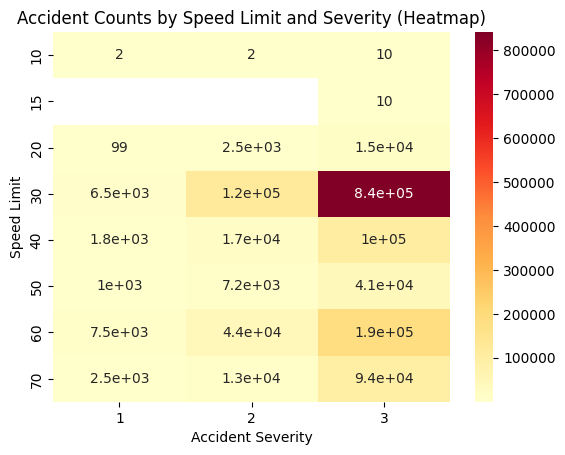

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Converting the result to a pandas DataFrame
accident_speed_pd = accident_speed.toPandas()

# Create the heatmap
sns.heatmap(accident_speed_pd.pivot_table(values='Accident Count', index='Speed_limit', columns='Accident_Severity', aggfunc='sum'), annot=True, cmap='YlOrRd')
plt.xlabel('Accident Severity')
plt.ylabel('Speed Limit')
plt.title('Accident Counts by Speed Limit and Severity (Heatmap)')
plt.show()


**Student 2: Aishwarya Nitin Sonar**

**Removing Data duplicates and identifying the numerical and categorical columns**

Checking the number of duplicate rows and printing the remaining rows.

In [20]:
from pyspark.sql.functions import col

# Identifying the colums for checking the duplicates
acc_columns = roadAccident_df.columns

# Grouping by columns and count occurrences
dup_acc_rows = roadAccident_df.groupBy(*acc_columns).count()

# Filtering for rows with count greater than 1 (for the duplicates)
dup_acc_rows = dup_acc_rows.filter(dup_acc_rows['count'] > 1)

# Counting the number of duplicate rows
duplicate_rows_count = dup_acc_rows.count()

print("No. of duplicate rows: ", duplicate_rows_count)


No. of duplicate rows:  0


Displaying the numerical columns

In [21]:
from pyspark.sql.functions import col

# Filtering the dataFrame to include only numeric columns
numeric_cols = [col_name for col_name, dtype in roadAccident_df.dtypes if dtype != 'string']
num_df = roadAccident_df.select(*numeric_cols)

# Generating the descriptive statistics for numeric columns
numeric_describe = num_df.describe()

# Showing the descriptive statistics
numeric_describe.show()


+-------+------------------+-------------------+------------------+------------------+-------------------+------------------+--------------------+------------------+--------------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|summary|               _c0|          Longitude|          Latitude|      Police_Force|  Accident_Severity|Number_of_Vehicles|Number_of_Casualties|       Day_of_Week|Local_Authority_(District)|    1st_Road_Class|   1st_Road_Number|       Speed_limit|    2nd_Road_Class|   2nd_Road_Number|Urban_or_Rural_Area|              Year|
+-------+------------------+-------------------+------------------+------------------+-------------------+------------------+--------------------+------------------+--------------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|  count|          

Identifying the numerical and categorical columns

In [22]:
# Getting the numerical columns
num_cols = [col_name for col_name, dtype in roadAccident_df.dtypes if dtype != 'string']

# Getting the categorical columns
cat_cols = [col_name for col_name, dtype in roadAccident_df.dtypes if dtype == 'string']

In [23]:
from pyspark.sql.functions import count

urban_rural_count = roadAccident_df.groupBy("Urban_or_Rural_Area").agg(count("*").alias("count"))

#Showing the results
urban_rural_count.show()


+-------------------+------+
|Urban_or_Rural_Area| count|
+-------------------+------+
|                  1|971913|
|                  3|    35|
|                  2|531942|
+-------------------+------+



**Visualisation 1: Accident counts for urban and rural areas**

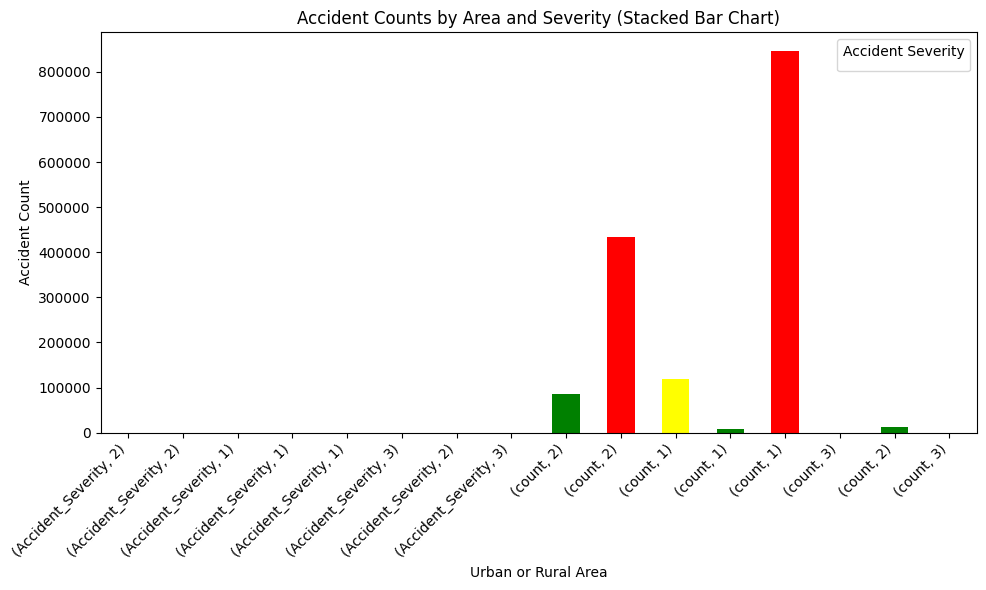

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating a stacked bar chart
roadAccident_df_with_severity = roadAccident_df.groupBy("Urban_or_Rural_Area", "Accident_Severity").agg(F.count("*").alias("count"))
roadAccident_df_with_severity_pd = roadAccident_df_with_severity.toPandas()

plt.figure(figsize=(10, 6))
roadAccident_df_with_severity_pd.set_index(['Urban_or_Rural_Area'], inplace=True)
roadAccident_df_with_severity_pd.unstack().plot(kind='bar', stacked=True, color=['red', 'yellow', 'green'])
plt.xlabel('Urban or Rural Area')
plt.ylabel('Accident Count')
plt.title('Accident Counts by Area and Severity (Stacked Bar Chart)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Accident Severity')
plt.tight_layout()
plt.show()


In [25]:
from pyspark.sql.functions import when

# Replacing values in a column
roadAccident_df = roadAccident_df.withColumn('Urban_or_Rural_Area', when(roadAccident_df['Urban_or_Rural_Area'] == 3, 1).otherwise(roadAccident_df['Urban_or_Rural_Area']))

In [26]:
from pyspark.sql.functions import count

# Selecting the 'Number_of_Vehicles' column
num_vehicles = roadAccident_df["Number_of_Vehicles"]

num_vehicles_count = roadAccident_df.groupBy("Number_of_Vehicles").agg(count("*").alias("count"))

#Showing the results
num_vehicles_count.show()

+------------------+------+
|Number_of_Vehicles| count|
+------------------+------+
|                12|    15|
|                22|     1|
|                 1|455567|
|                13|    12|
|                 6|  1748|
|                16|     4|
|                 3|120105|
|                20|     2|
|                 5|  5651|
|                15|     3|
|                 9|   132|
|                17|     1|
|                 4| 25495|
|                 8|   293|
|                 7|   611|
|                10|    63|
|                11|    26|
|                14|     7|
|                 2|894142|
|                18|     4|
+------------------+------+
only showing top 20 rows



**Visualisation 2: Accident counts by number of vehicles involved**

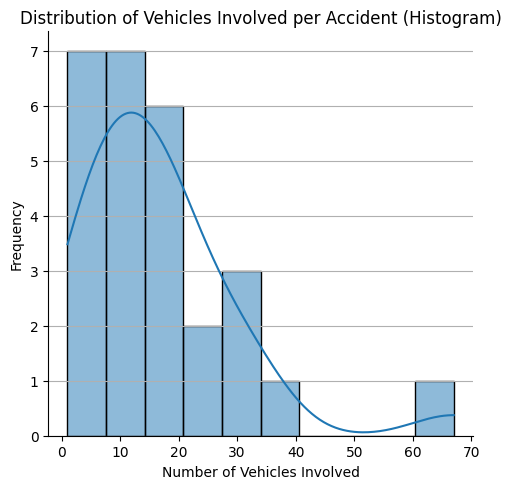

In [27]:
import seaborn as sns
import pandas as pd

num_vehicles_count_pd = num_vehicles_count.toPandas()

# Create a histogram
sns.displot(
    num_vehicles_count_pd["Number_of_Vehicles"],
    kind="hist",
    kde=True,
    bins=10
)
plt.xlabel("Number of Vehicles Involved")
plt.ylabel("Frequency")
plt.title("Distribution of Vehicles Involved per Accident (Histogram)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


**Visualisation 3: Detailed view of the distribution of accident counts within** **each weather condition category**

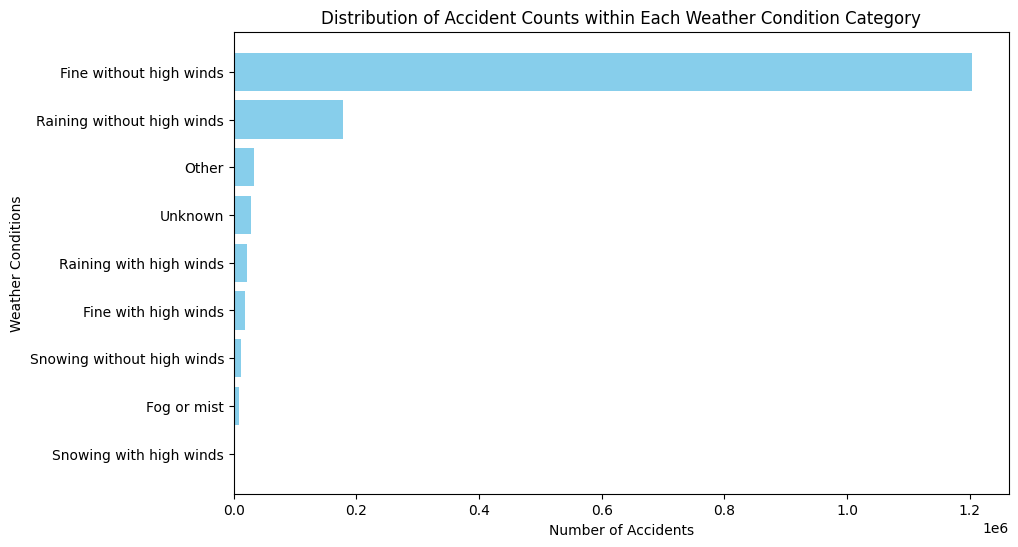

In [28]:
import matplotlib.pyplot as plt

# Grouping the data by 'Weather_Conditions' and counting the number of accidents in each category
weather_cnts = roadAccident_df.groupBy('Weather_Conditions').count().orderBy('count', ascending=False).collect()

# Extracting labels and accident_counts
labels = [row['Weather_Conditions'] for row in weather_cnts]
accident_counts = [row['count'] for row in weather_cnts]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.barh(labels, accident_counts, color='skyblue')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Conditions')
plt.title('Distribution of Accident Counts within Each Weather Condition Category')
plt.gca().invert_yaxis()  # Invert y-axis to display the highest count at the top
plt.show()


**Student 3: Purvi Dawda**

**Analysing the data for feature extraction**

In [29]:
from pyspark.sql.functions import count

# Selecting the 'Number_of_Casualties' column
num_casualities = roadAccident_df["Number_of_Casualties"]

casuality_count = roadAccident_df.groupBy("Number_of_Casualties").agg(count("*").alias("count"))

#Showing the results
casuality_count.show()

+--------------------+-------+
|Number_of_Casualties|  count|
+--------------------+-------+
|                  28|      1|
|                  26|      7|
|                  12|     47|
|                  22|     11|
|                   1|1153639|
|                  13|     42|
|                   6|   3486|
|                  16|     15|
|                   3|  68848|
|                  20|      4|
|                  40|      2|
|                   5|   9215|
|                  19|      9|
|                  41|      2|
|                  15|     16|
|                   9|    246|
|                  17|     15|
|                  35|      1|
|                   4|  25042|
|                   8|    511|
+--------------------+-------+
only showing top 20 rows



**Visualisation 1: Number of accidents by number of casualties**

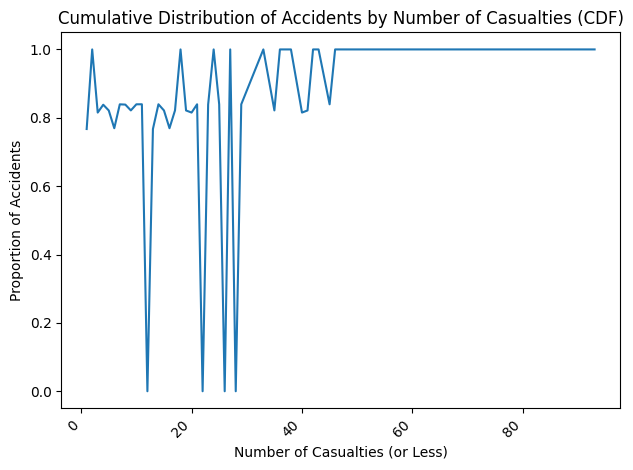

In [30]:
import seaborn as sns
import pandas as pd

casuality_count_pd = casuality_count.toPandas()
casuality_count_pd['cumulative_count'] = casuality_count_pd['count'].cumsum()
casuality_count_pd['pct_of_total'] = casuality_count_pd['cumulative_count'] / casuality_count_pd['count'].sum()

# Creating a CDF plot
sns.lineplot(
    x = "Number_of_Casualties",
    y = "pct_of_total",
    data=casuality_count_pd
)
plt.xlabel("Number of Casualties (or Less)")
plt.ylabel("Proportion of Accidents")
plt.title("Cumulative Distribution of Accidents by Number of Casualties (CDF)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [31]:
# Getting the schema of the road accident dataframe
schema = roadAccident_df.schema

# Iterating through the schema to identify string-type columns
for field in schema.fields:
    if field.dataType == 'string':
        col_name = field.name
        unique_values_count = roadAccident_df.select(col_name).distinct().count()
        print(f"The '{col_name}' column has {unique_values_count} unique values.")
roadAccident_df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- Accident_Index: string (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Police_Force: integer (nullable = true)
 |-- Accident_Severity: integer (nullable = true)
 |-- Number_of_Vehicles: integer (nullable = true)
 |-- Number_of_Casualties: integer (nullable = true)
 |-- Date: string (nullable = true)
 |-- Day_of_Week: integer (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Local_Authority_(District): integer (nullable = true)
 |-- 1st_Road_Class: integer (nullable = true)
 |-- 1st_Road_Number: integer (nullable = true)
 |-- Road_Type: string (nullable = true)
 |-- Speed_limit: integer (nullable = true)
 |-- Junction_Control: string (nullable = true)
 |-- 2nd_Road_Class: integer (nullable = true)
 |-- 2nd_Road_Number: integer (nullable = true)
 |-- Pedestrian_Crossing-Human_Control: string (nullable = true)
 |-- Pedestrian_Crossing-Physical_Facilities: string (nullable = tr

In [32]:
from pyspark.sql.functions import count_distinct

# Counting the number of distinct values in the 'Accident_Index' column
unique_accident_count = roadAccident_df.select(roadAccident_df['Accident_Index']).distinct().count()

print(unique_accident_count)


927301


Because the feature - Accident Index is just a count and adds no value to the model, we can drop the feature

In [33]:
roadAccident_df = roadAccident_df.drop('Accident_Index')

In [34]:
roadAccident_df.show()

+---+---------+---------+------------+-----------------+------------------+--------------------+----------+-----------+-------------------+--------------------------+--------------+---------------+------------------+-----------+--------------------+--------------+---------------+---------------------------------+---------------------------------------+--------------------+--------------------+-----------------------+--------------------------+-------------------+-------------------+-------------------------------------------+----+
|_c0|Longitude| Latitude|Police_Force|Accident_Severity|Number_of_Vehicles|Number_of_Casualties|      Date|Day_of_Week|               Time|Local_Authority_(District)|1st_Road_Class|1st_Road_Number|         Road_Type|Speed_limit|    Junction_Control|2nd_Road_Class|2nd_Road_Number|Pedestrian_Crossing-Human_Control|Pedestrian_Crossing-Physical_Facilities|    Light_Conditions|  Weather_Conditions|Road_Surface_Conditions|Special_Conditions_at_Site|Carriageway_Haza

**Visualisation 2: Proportion of each category within two binary categorical** **variables: 'Urban_or_Rural_Area' and 'Did_Police_Officer_Attend_Scene_of_Accident'**

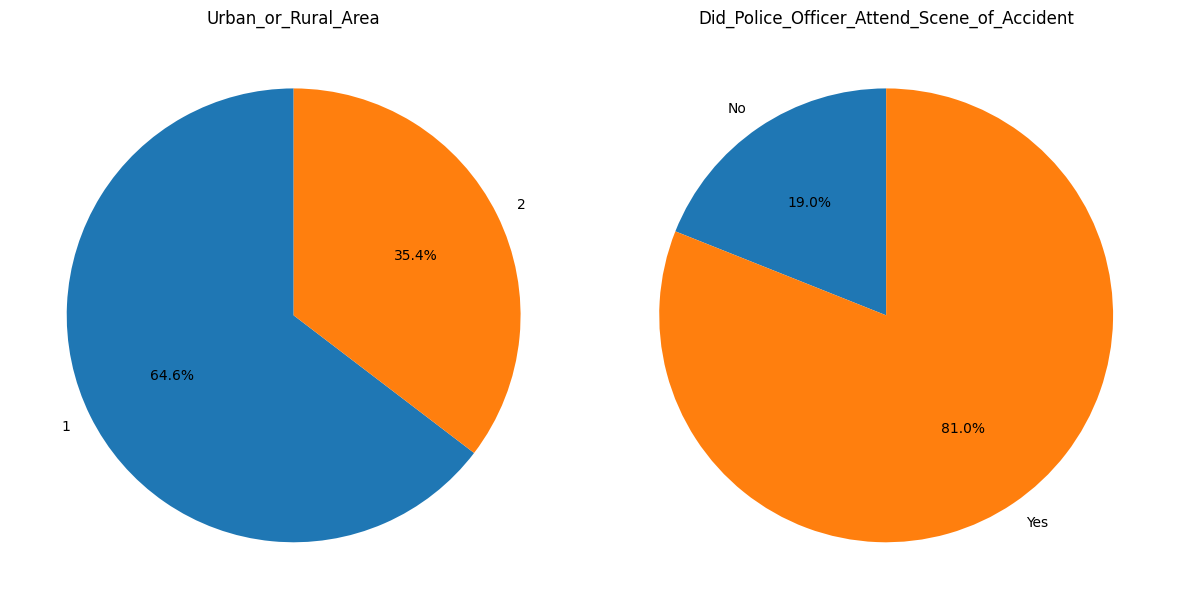

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Defining binary categorical variables
cat_variables = ['Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident']

# Creating subplots
fig, axes = plt.subplots(nrows=1, ncols=len(cat_variables), figsize=(12, 6))

# Plotting pie charts for each binary variable
for i, var in enumerate(cat_variables):
    # Calculating the proportions
    proportions_cnt = roadAccident_df.groupBy(var).count().toPandas()

    # Plotting pie chart
    axes[i].pie(proportions_cnt['count'], labels=proportions_cnt[var], autopct='%1.1f%%', startangle=90)
    axes[i].set_title(var)

plt.tight_layout()
plt.show()


**Visualisation 3: Comparing Accident Severity Across Forces**

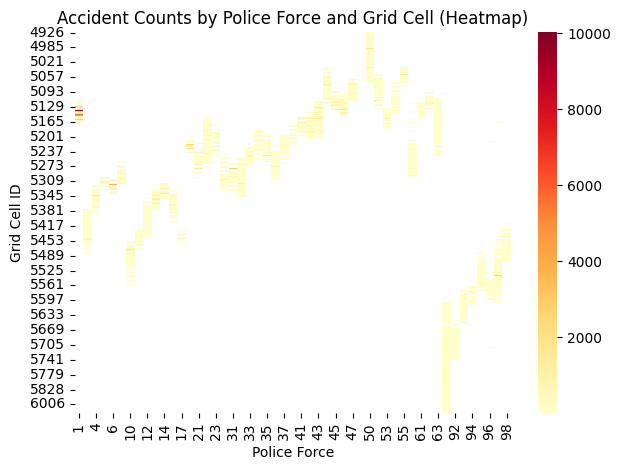

In [37]:
from pyspark.sql.functions import count

# 1. Defining a spatial unit
grid_size = 0.1
roadAccident_df = roadAccident_df.withColumn("grid_id", F.floor(F.col('latitude') / grid_size) * 10  + F.floor(F.col('longitude') / grid_size))

# 2. Grouping accidents by grid and police force, then counting the occurrences
severity_counts = roadAccident_df.groupBy("grid_id", "police_force", "accident_severity").agg(count("*").alias("accident_count"))

# 3. Converting the results to a pandas DataFrame and reshape for heatmap
severity_counts_pd = severity_counts.toPandas().pivot_table(values='accident_count', index='grid_id', columns='police_force')

# 4. Creating a heatmap using seaborn
sns.heatmap(severity_counts_pd, cmap='YlOrRd')
plt.xlabel("Police Force")
plt.ylabel("Grid Cell ID")
plt.title("Accident Counts by Police Force and Grid Cell (Heatmap)")
plt.tight_layout()
plt.show()


**Student 1 & 2: Kruttika Jamalpuram & Aishwarya Nitin Sonar**

In [38]:
roadAccident_df.drop('Year')

DataFrame[_c0: int, Longitude: double, Latitude: double, Police_Force: int, Accident_Severity: int, Number_of_Vehicles: int, Number_of_Casualties: int, Date: string, Day_of_Week: int, Time: timestamp, Local_Authority_(District): int, 1st_Road_Class: int, 1st_Road_Number: int, Road_Type: string, Speed_limit: int, Junction_Control: string, 2nd_Road_Class: int, 2nd_Road_Number: int, Pedestrian_Crossing-Human_Control: string, Pedestrian_Crossing-Physical_Facilities: string, Light_Conditions: string, Weather_Conditions: string, Road_Surface_Conditions: string, Special_Conditions_at_Site: string, Carriageway_Hazards: string, Urban_or_Rural_Area: int, Did_Police_Officer_Attend_Scene_of_Accident: string, grid_id: bigint]

In [39]:
from pyspark.sql.functions import dayofmonth, month, year, to_date

# Converting string date to PySpark date type with the correct format
roadAccident_df = roadAccident_df.withColumn("Date", to_date(col("Date"), "dd/MM/yyyy"))

# Extracting day, month, and year from the 'Date' column
roadAccident_df = roadAccident_df.withColumn("day", dayofmonth("Date"))
roadAccident_df = roadAccident_df.withColumn("month", month("Date"))
roadAccident_df = roadAccident_df.withColumn("Year", year("Date"))

In [40]:
roadAccident_df.show()

+---+---------+---------+------------+-----------------+------------------+--------------------+----------+-----------+-------------------+--------------------------+--------------+---------------+------------------+-----------+--------------------+--------------+---------------+---------------------------------+---------------------------------------+--------------------+--------------------+-----------------------+--------------------------+-------------------+-------------------+-------------------------------------------+----+-------+---+-----+
|_c0|Longitude| Latitude|Police_Force|Accident_Severity|Number_of_Vehicles|Number_of_Casualties|      Date|Day_of_Week|               Time|Local_Authority_(District)|1st_Road_Class|1st_Road_Number|         Road_Type|Speed_limit|    Junction_Control|2nd_Road_Class|2nd_Road_Number|Pedestrian_Crossing-Human_Control|Pedestrian_Crossing-Physical_Facilities|    Light_Conditions|  Weather_Conditions|Road_Surface_Conditions|Special_Conditions_at_Sit

In [41]:
# Dropring the "Date" and "Time" columns
roadAccident_df = roadAccident_df.drop("Date", "Time")

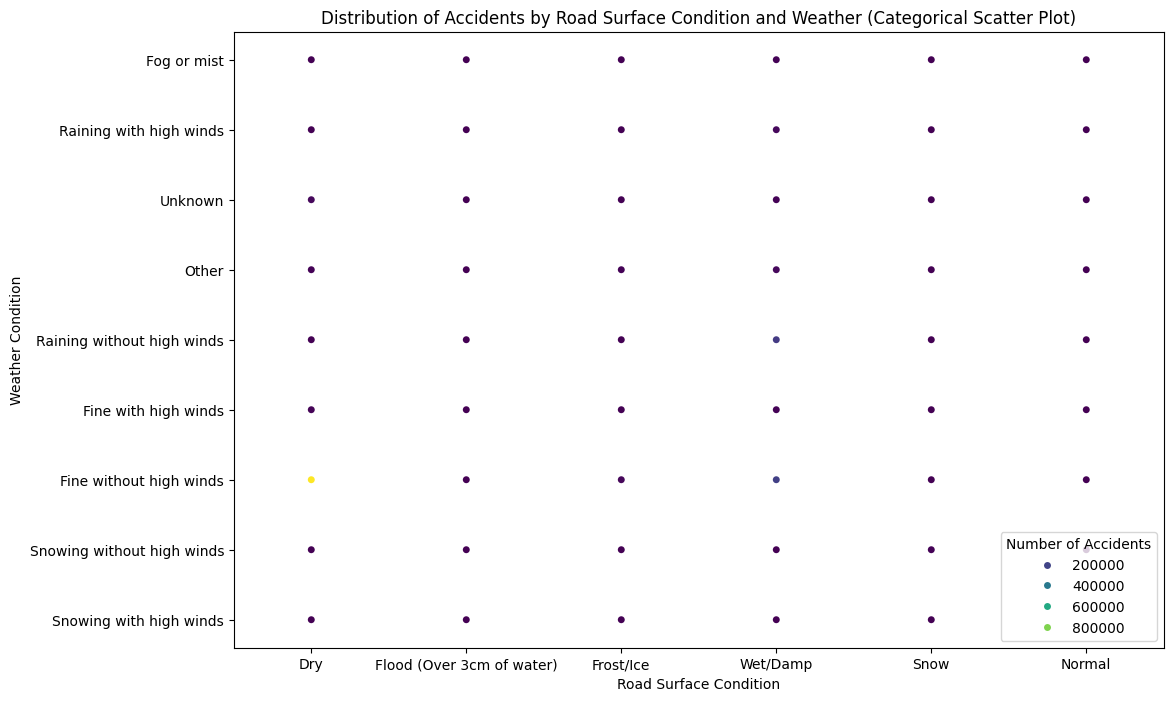

In [42]:
from pyspark.sql.functions import col, count
import matplotlib.pyplot as plt
import seaborn as sns

accident_with_conditions = roadAccident_df.groupBy("Road_Surface_Conditions", "Weather_Conditions").agg(count("*").alias("Number_of_Accidents"))

accident_with_conditions_pd = accident_with_conditions.toPandas()

plt.figure(figsize=(12, 8))

# Creating a categorical scatter plot using seaborn
sns.swarmplot(
    x="Road_Surface_Conditions",
    y="Weather_Conditions",
    hue="Number_of_Accidents",
    palette="viridis",
    data=accident_with_conditions_pd,
)
plt.xlabel("Road Surface Condition")
plt.ylabel("Weather Condition")
plt.title("Distribution of Accidents by Road Surface Condition and Weather (Categorical Scatter Plot)")
plt.legend(title="Number of Accidents")
plt.show()


---
# **Task 2 - Model Selection and Implementation (25 marks)**
---


Splitting the data in train and test for model selection and implementation

In [43]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, FloatType, IntegerType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.datasets import make_blobs


# Generating a sample dataset
X, y = make_blobs(n_samples=500, centers=2, n_features=2, random_state=0)

# Converting NumPy arrays to Python native types
X_list = X.tolist()
y_list = y.tolist()

# Defining the schema for the DataFrame
# Accident Severity is the target variable
# We are predicting the Accident Severity using the Features - 'Road_Surface_Conditions' and 'Weather_Conditions'
schema = StructType([
    StructField("Road_Surface_Conditions", FloatType(), True),
    StructField("Weather_Conditions", FloatType(), True),
    StructField("Accident_Severity", IntegerType(), True)
])

# Creating a list of rows with the Python native types
rows = [(float(X_list[i][0]), float(X_list[i][1]), int(y_list[i])) for i in range(len(X_list))]

# Creating a DataFrame using the defined schema and data rows
model_df = spark.createDataFrame(rows, schema)

# Assemble the above features into a vector
assembler = VectorAssembler(inputCols=["Road_Surface_Conditions","Weather_Conditions"], outputCol="features")
dataset = assembler.transform(model_df)

# Splitting the dataset into training and testing sets
train_data, test_data = dataset.randomSplit([0.8, 0.2], seed=0)

**Student 1: Kruttika Jamalpuram**

**Model : Support Vector Machine**

* Support Vector Classifier, is a powerful machine learning algorithm for classification tasks.

* It belongs to the group of Support Vector Machines (SVMS), and it aims to find a Hyperplane in a high-dimensional space that best separates the data points of different classes.

* To improve performance, parameters such as kernel type, regularization parameter (c), and kernel coefficient (gamma) are adjusted.

In [44]:
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Creating a LinearSVC model
linear_svm_mod = LinearSVC(maxIter=10, regParam=0.1, labelCol="Accident_Severity", featuresCol="features")

# Training the model
model_svm_tr = linear_svm_mod.fit(train_data)

# Making predictions on the test data
prediction_svm = model_svm_tr.transform(test_data)

# Evaluate accuracy
eval = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="accuracy")
accuracy_svm = eval.evaluate(prediction_svm)
print(f"SVM Accuracy: {accuracy_svm:.2f}")


SVM Accuracy: 0.95


**Student 2: Aishwarya Nitin Sonar**

**Model: Random Forest Classifier**

*   Random Forest Classifier combines predictions from multiple decision trees to enhance accuracy and reliability through ensemble learning.
*   Each tree in the Random Forest is trained on a random subset of data and features, reducing overfitting and increasing model robustness.



In [45]:
# Creating a RandomForestClassifier model
rf = RandomForestClassifier(numTrees=100, labelCol="Accident_Severity", featuresCol="features", seed=0)

# Training the model
model_rf = rf.fit(train_data)

# Making predictions on the test data
prediction_rf = model_rf.transform(test_data)

# Evaluating accuracy
eval = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="accuracy")
accuracy_rf = eval.evaluate(prediction_rf)
print(f"Accuracy: {accuracy_rf:.2f}")

Accuracy: 0.96


**Student 3: Purvi Dawda**

**Model: Logistic Regression**

- Logistic regression is a statistical approach for binary classification, predicting outcomes with two possible classes (e.g., yes/no). It uses a logistic (sigmoid) function to relate features to the probability of the outcome.

- The model's decision boundary, defined by its coefficients, separates these classes in feature space. Training involves maximizing the likelihood of observed outcomes through maximum likelihood estimation.


In [46]:
from pyspark.ml.classification import LogisticRegression

# Creating a LogisticRegression model
lr = LogisticRegression(labelCol="Accident_Severity", featuresCol="features")

# Training the model
model_lr = lr.fit(train_data)

# Making predictions on the test data
prediction_lr = model_lr.transform(test_data)

# Evaluating the accuracy
eval = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="accuracy")
accuracy_lr = eval.evaluate(prediction_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")

Logistic Regression Accuracy: 0.95


---
# **Task 3 - Model Parameter Tuning (20 marks)**
---


**Student 1: Kruttika Jamalpuram**

Parameter tuning with SVC by adding the max iterations and regParam parameter using the ParamGridBuilder

In [47]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Creating a LinearSVC model
svm = LinearSVC(labelCol="Accident_Severity", featuresCol="features")

# Defining a parameter grid
parameter_grid_bul = ParamGridBuilder() \
    .addGrid(svm.maxIter, [2, 3, 5]) \
    .addGrid(svm.regParam, [0.1, 0.01]) \
    .build()

# Setting up cross-validation
crossvalidation = CrossValidator(estimator=svm,
                          estimatorParamMaps=parameter_grid_bul,
                          evaluator=eval,
                          numFolds=3)

# Training the model with cross-validation
cv_model_svm = crossvalidation.fit(train_data)

# Get the best model from cross-validation
best_svm_model = cv_model_svm.bestModel

# Making predictions on the test data
prediction_svm = best_svm_model.transform(test_data)

# Evaluating accuracy
eval = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="accuracy")
accuracy_svm = eval.evaluate(prediction_svm)
print(f"SVM Accuracy: {accuracy_svm:.2f}")

print(f"Best Max Iterations: {best_svm_model.getMaxIter()}")
print(f"Best Regularization Parameter: {best_svm_model.getRegParam()}")


SVM Accuracy: 0.96
Best Max Iterations: 2
Best Regularization Parameter: 0.01


**Student 2: Aishwarya Nitin Sonar**

Parameter tuning with MulticlassClassificationEvaluator and Random Forest Classifier

In [48]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Creating Random Forest Classifier
rf = RandomForestClassifier(labelCol="Accident_Severity", featuresCol="features", seed=0)

# Defining a parameter grid for hyperparameter tuning
parameter_grid_bul = ParamGridBuilder() \
    .addGrid(rf.maxDepth, [5, 10, 15, 20]) \
    .addGrid(rf.numTrees, [100, 200, 300]) \
    .addGrid(rf.featureSubsetStrategy, ['auto', 'sqrt', 'log2']) \
    .build()

# Creating CrossValidator for hyperparameter tuning
crossvalidation = CrossValidator(estimator=rf,
                          estimatorParamMaps=parameter_grid_bul,
                          evaluator=MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="accuracy"),
                          numFolds=3)

# Train the model with cross-validation
cv_model = crossvalidation.fit(train_data)

# Get the best model from cross-validation
best_rf_model = cv_model.bestModel

# Make predictions on the test data using the best model
prediction_rf = best_rf_model.transform(test_data)

# Evaluate accuracy
eval = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="accuracy")
accuracy_rf= eval.evaluate(prediction_rf)
print(f"Accuracy: {accuracy_rf:.2f}")

# Print the best parameters
print(f"Best Max Depth: {best_rf_model.getMaxDepth()}")
print(f"Best Number of Trees: {best_rf_model.getNumTrees}")
print(f"Best Feature Subset Strategy: {best_rf_model.getFeatureSubsetStrategy()}")


Accuracy: 0.97
Best Max Depth: 10
Best Number of Trees: 200
Best Feature Subset Strategy: log2


**Student 3: Purvi Dawda**

Logistic Regression with Parameter Tuning

In [51]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Creating a LogisticRegression model
lr = LogisticRegression(labelCol="Accident_Severity", featuresCol="features")

# Defining a parameter grid
parameter_grid_buil = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.1, 0.01, 0.001]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.1, 0.5, 0.7, 1.0]) \
    .addGrid(lr.maxIter, [10, 50, 100, 200]) \
    .build()

# Setting up cross-validation
crossvalidation = CrossValidator(estimator=lr,
                          estimatorParamMaps=parameter_grid_buil,
                          evaluator=eval,
                          numFolds=4)  # Use 3 folds for cross-validation

# Training the model with cross-validation
cv_model_lr = crossvalidation.fit(train_data)

# Making predictions on the test data
prediction_lr = cv_model_lr.transform(test_data)

# Evaluating accuracy
accuracy_lr = eval.evaluate(prediction_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")

# Best hyperparameters
best_regParam = cv_model_lr.bestModel.getRegParam()
best_elasticNetParam = cv_model_lr.bestModel.getElasticNetParam()
best_maxIter = cv_model_lr.bestModel.getMaxIter()
print(f"Best Regularization Parameter: {best_regParam}")
print(f"Best Elastic Net Parameter: {best_elasticNetParam}")
print(f"Best Max Iterations: {best_maxIter}")


Logistic Regression Accuracy: 0.93
Best Regularization Parameter: 0.1
Best Elastic Net Parameter: 1.0
Best Max Iterations: 10


---
# **Task 4 - Model Evaluation and Accuracy Calculation (20 marks)**
---

**Student 1: Kruttika Jamalpuram**

**SVC**

In [52]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Evaluating accuracy
accuracy_svm = eval.evaluate(prediction_svm)
print(f"SVM Accuracy: {accuracy_svm:.2f}")

# Evaluating precision, recall, and F1-score
multi_eval = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction")
precision_svm = multi_eval.evaluate(prediction_svm, {multi_eval.metricName: "weightedPrecision"})
recall_svm = multi_eval.evaluate(prediction_svm, {multi_eval.metricName: "weightedRecall"})
f1_score_svm = multi_eval.evaluate(prediction_svm, {multi_eval.metricName: "f1"})

# Evaluating AUC-ROC
bin_eval = BinaryClassificationEvaluator(labelCol="Accident_Severity", rawPredictionCol="rawPrediction")
auc_roc_svm = bin_eval.evaluate(prediction_svm, {bin_eval.metricName: "areaUnderROC"})

print(f"SVM Precision: {precision_svm:.2f}")
print(f"SVM Recall: {recall_svm:.2f}")
print(f"SVM F1 Score: {f1_score_svm:.2f}")
print(f"SVM AUC-ROC: {auc_roc_svm:.2f}")


SVM Accuracy: 0.96
SVM Precision: 0.96
SVM Recall: 0.96
SVM F1 Score: 0.96
SVM AUC-ROC: 0.99


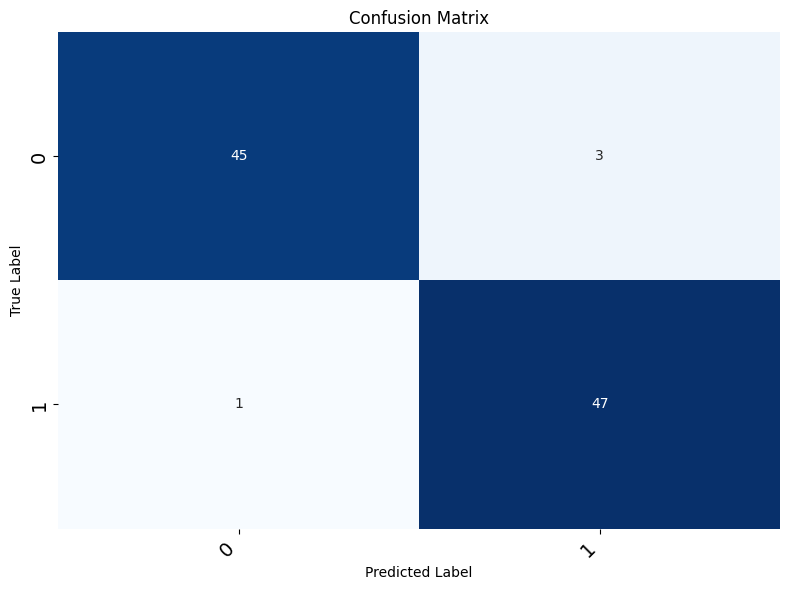

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Extracting true labels and predicted labels
true_labels = prediction_svm.select("Accident_Severity").rdd.map(lambda row: row[0]).collect()
predicted_labels = prediction_svm.select("prediction").rdd.map(lambda row: row[0]).collect()

# Computing confusion matrix
conf_mat = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Student 2: Aishwarya Nitin Sonar**

**Random Forest**

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluating accuracy
eval = MulticlassClassificationEvaluator(labelCol="Accident_Severity", predictionCol="prediction", metricName="accuracy")
accuracy_rf = eval.evaluate(prediction_rf)
print(f"Accuracy: {accuracy_rf:.2f}")

# Extracting labels and predictions for further evaluation
predicted_rf = prediction_rf.select("prediction").rdd.flatMap(lambda x: x).collect()
labeled_rf = prediction_rf.select(col("Accident_Severity")).rdd.flatMap(lambda x: x).collect()

precision = precision_score(labeled_rf, predicted_rf)
recall = recall_score(labeled_rf, predicted_rf)
f1 = f1_score(labeled_rf, predicted_rf)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Accuracy: 0.97
Precision: 0.96
Recall: 0.98
F1-Score: 0.97


Confusion Matrix:
[[46  2]
 [ 1 47]]


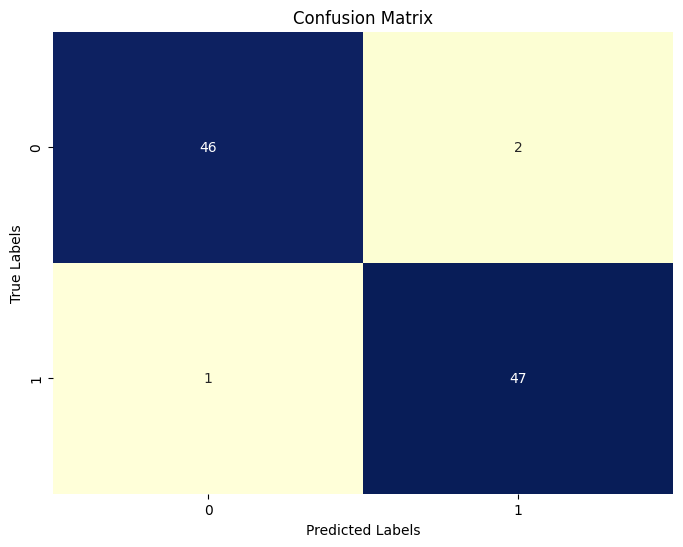

In [55]:
from sklearn.metrics import confusion_matrix

# Computing the confusion matrix
conf_mat = confusion_matrix(labeled_rf, predicted_rf)

print("Confusion Matrix:")
print(conf_mat)

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, cmap='YlGnBu', fmt='g', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

**Student 3: Purvi Dawda**

**Logistic Regression**

In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluating accuracy
accuracy_lr = eval.evaluate(prediction_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")

# Extracting labels and predictions for further evaluation
predicted_lr = prediction_lr.select("prediction").rdd.flatMap(lambda x: x).collect()
labeled_lr = prediction_lr.select(col("Accident_Severity")).rdd.flatMap(lambda x: x).collect()

precision = precision_score(labeled_lr, predicted_lr)
recall = recall_score(labeled_lr, predicted_lr)
f1 = f1_score(labeled_lr, predicted_lr)

print(f"Logistic Regression Precision: {precision:.2f}")
print(f"Logistic Regression Recall: {recall:.2f}")
print(f"Logistic Regression F1-Score: {f1:.2f}")

Logistic Regression Accuracy: 0.93
Logistic Regression Precision: 0.90
Logistic Regression Recall: 0.96
Logistic Regression F1-Score: 0.93


Confusion Matrix:
[[43  5]
 [ 2 46]]


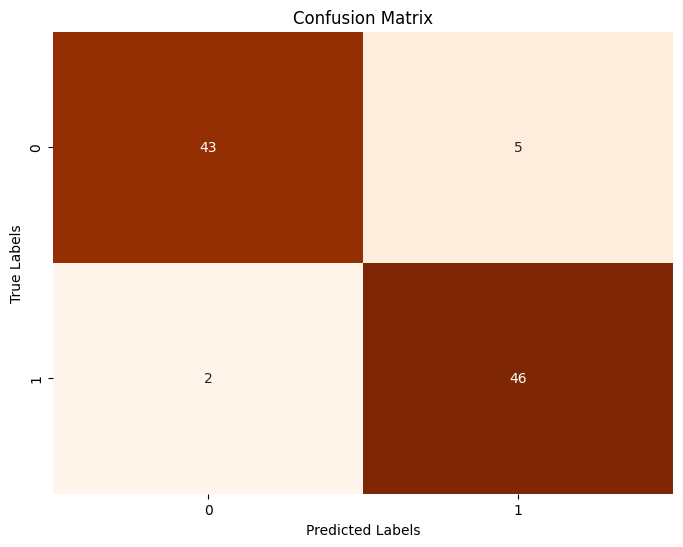

In [57]:
from sklearn.metrics import confusion_matrix

# Computing the confusion matrix
conf_matrix = confusion_matrix(labeled_lr, predicted_lr)

print("Confusion Matrix:")
print(conf_matrix)

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Oranges', fmt='g', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

---
# **Task 5 - Results Visualization or Printing (5 marks)**
---

**Student 1: Kruttika Jamalpuram**

**Plotting the validation metrics for SVM model**

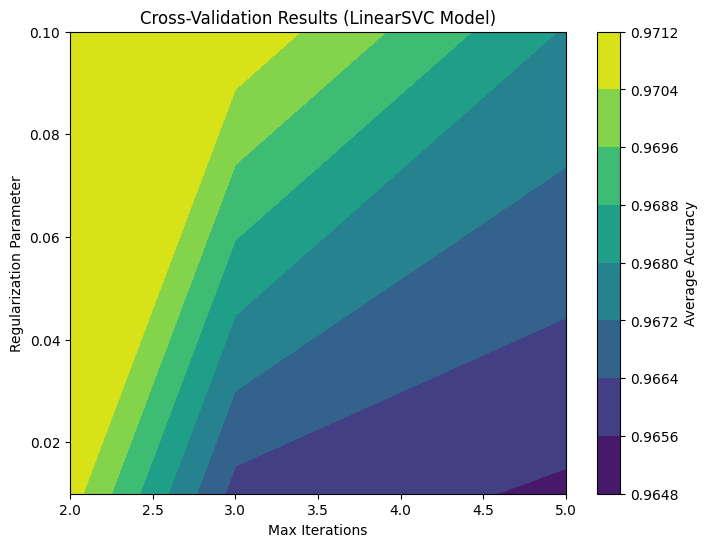

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Getting the list of validation metrics from the CrossValidatorModel
validation_metrics = cv_model_svm.avgMetrics

# Defining the parameter grid values for plotting
max_iterations = [2, 3, 5]
reg_params = [0.1, 0.01]

# Creating a mesh grid for plotting
xx, yy = np.meshgrid(max_iterations, reg_params)

# Reshaping the validation metrics to match the mesh grid shape
grid = np.array(validation_metrics).reshape(xx.shape)

# Plotting the validation metrics
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, grid, cmap='viridis')
plt.colorbar(label='Average Accuracy')
plt.xlabel('Max Iterations')
plt.ylabel('Regularization Parameter')
plt.title('Cross-Validation Results (LinearSVC Model)')
plt.show()


**Plotting each metric against accuracy**

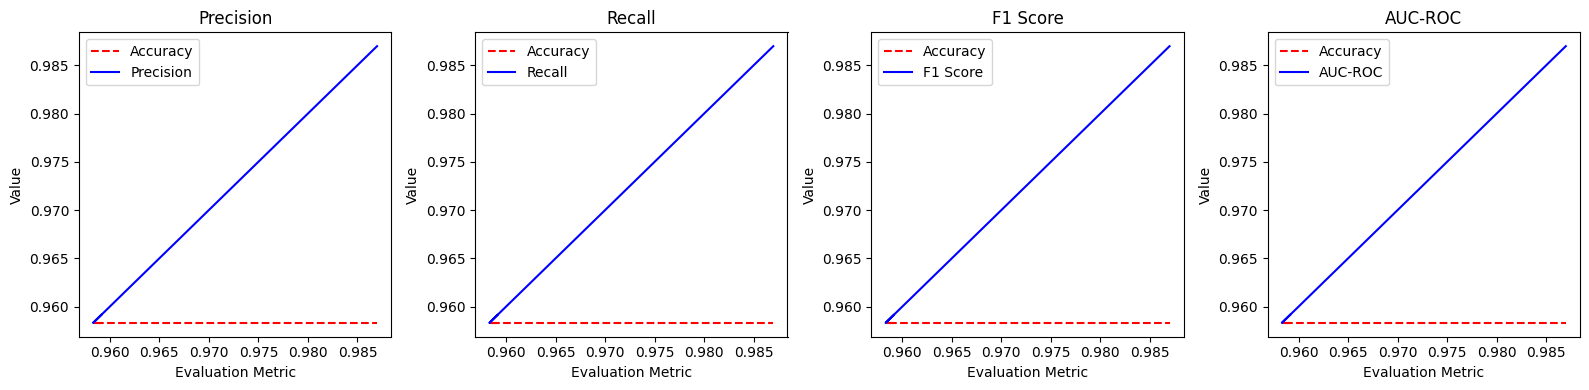

In [59]:
import matplotlib.pyplot as plt

# Creating a pandas DataFrame for the results
metricResults = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1 Score", "AUC-ROC"],
    "Value": [precision_svm, recall_svm, f1_score_svm, auc_roc_svm]
})

# Plotting each metric against the accuracy
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
for i, metric in enumerate(metricResults.Metric):
    axs[i].plot(metricResults.Value, [accuracy_svm]*len(metricResults.Value), 'r--', label='Accuracy')
    axs[i].plot(metricResults.Value, metricResults.Value, 'b-', label=metric)
    axs[i].set_xlabel('Evaluation Metric')
    axs[i].set_ylabel('Value')
    axs[i].set_title(metric)
    axs[i].legend()
plt.tight_layout()
plt.show()

**Plotting the histogram for Numerical features**

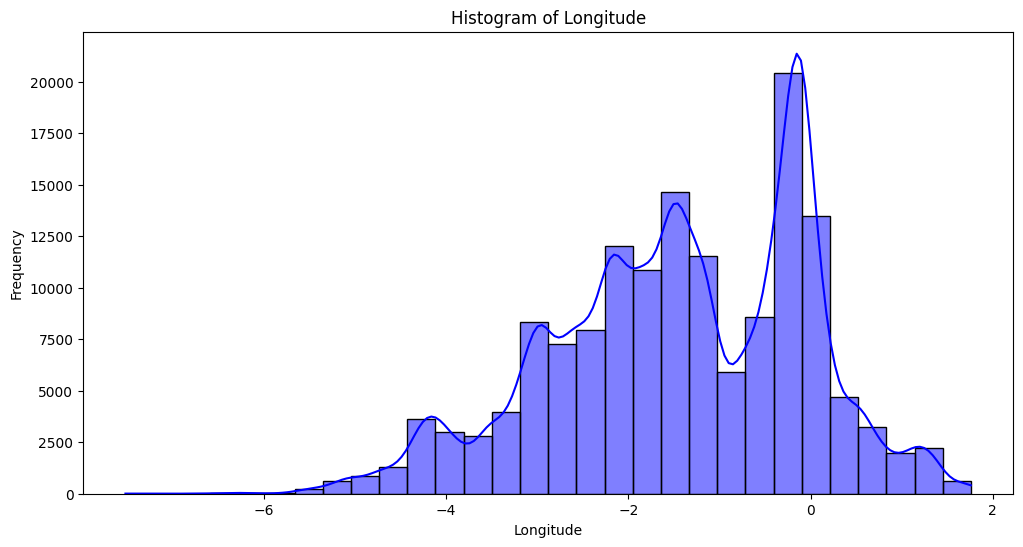

In [60]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns

# Sample a portion of the data
sampled_roadAccident_df = roadAccident_df.sample(fraction=0.1, seed=42)

# Converting PySpark DataFrame to pandas DataFrame
accident_df_pd = sampled_roadAccident_df.toPandas()

# Histogram for Numerical Features
plt.figure(figsize=(12, 6))
sns.histplot(data=accident_df_pd, x='Longitude', bins=30, kde=True, color='blue')
plt.title('Histogram of Longitude')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.show()


**Box plot for Numerical features**

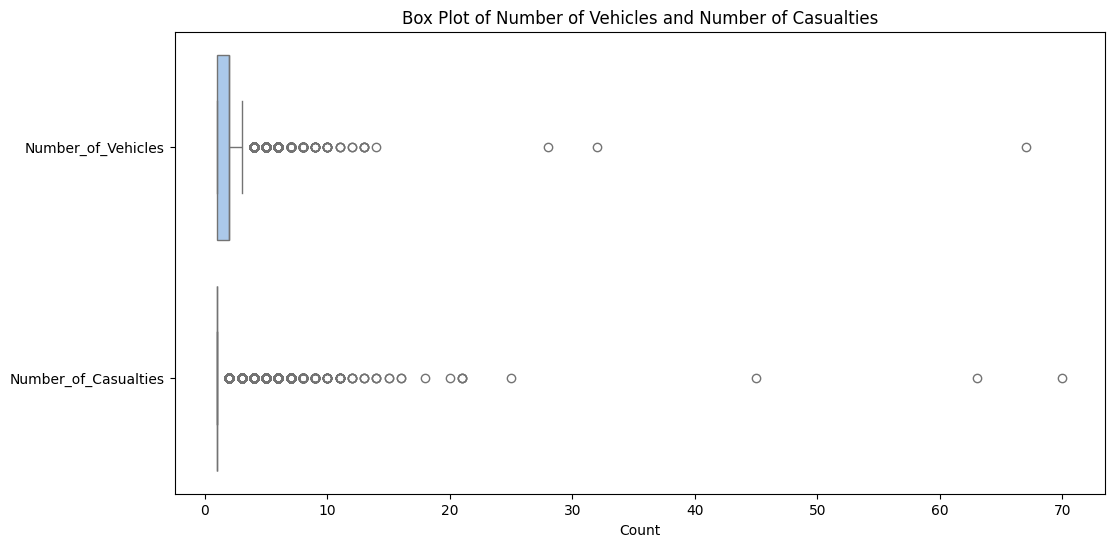

In [61]:
# Box Plot for Numerical Features
plt.figure(figsize=(12, 6))
sns.boxplot(data=accident_df_pd[['Number_of_Vehicles', 'Number_of_Casualties']], orient='h', palette='pastel')
plt.title('Box Plot of Number of Vehicles and Number of Casualties')
plt.xlabel('Count')
plt.show()

**Student 2: Aishwarya Nitin Sonar**

**Bar plot for accuracy comparison between different classification algorithms**

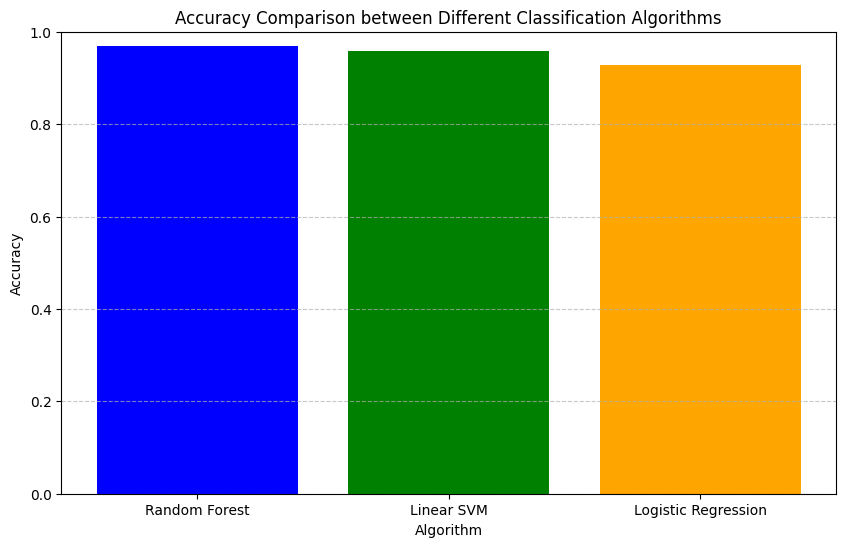

In [62]:
import matplotlib.pyplot as plt

# Bar plot for accuracy comparison between different classification algorithms
algo_nms = ['Random Forest', 'Linear SVM', 'Logistic Regression']
accys = [accuracy_rf, accuracy_svm, accuracy_lr]
plt.figure(figsize=(10, 6))
plt.bar(algo_nms, accys, color=['blue', 'green', 'orange'])
plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison between Different Classification Algorithms')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Correlation matrix for numeric columns**

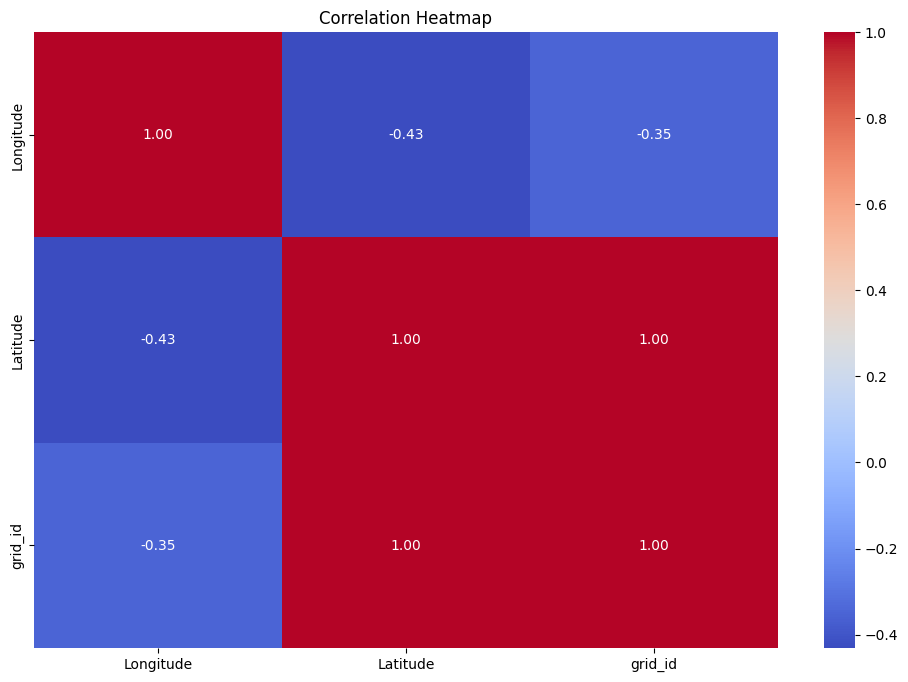

In [63]:
numeric_columns = [col for col, dtype in accident_df_pd.dtypes.items() if dtype in ['int', 'float']]

# Compute the correlation matrix for numeric columns only
correlation_matrix = accident_df_pd[numeric_columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


**Scatter Plot for Longitude vs. Latitude**

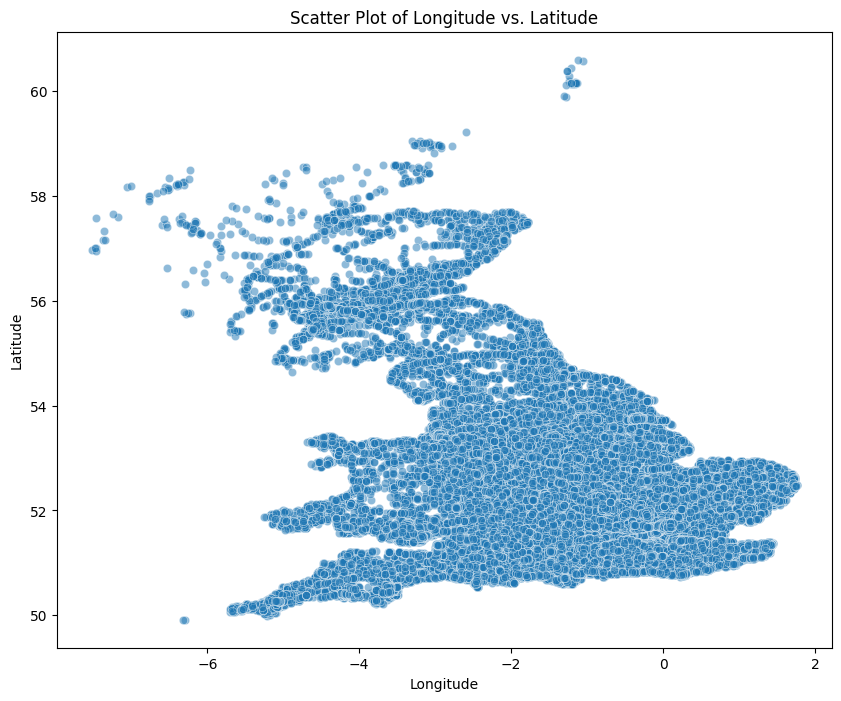

In [64]:
# Scatter Plot for Longitude vs. Latitude
plt.figure(figsize=(10, 8))
sns.scatterplot(data=accident_df_pd, x='Longitude', y='Latitude', alpha=0.5)
plt.title('Scatter Plot of Longitude vs. Latitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**Student 3: Purvi Dawda**

**Plotting the params against Accuracy**

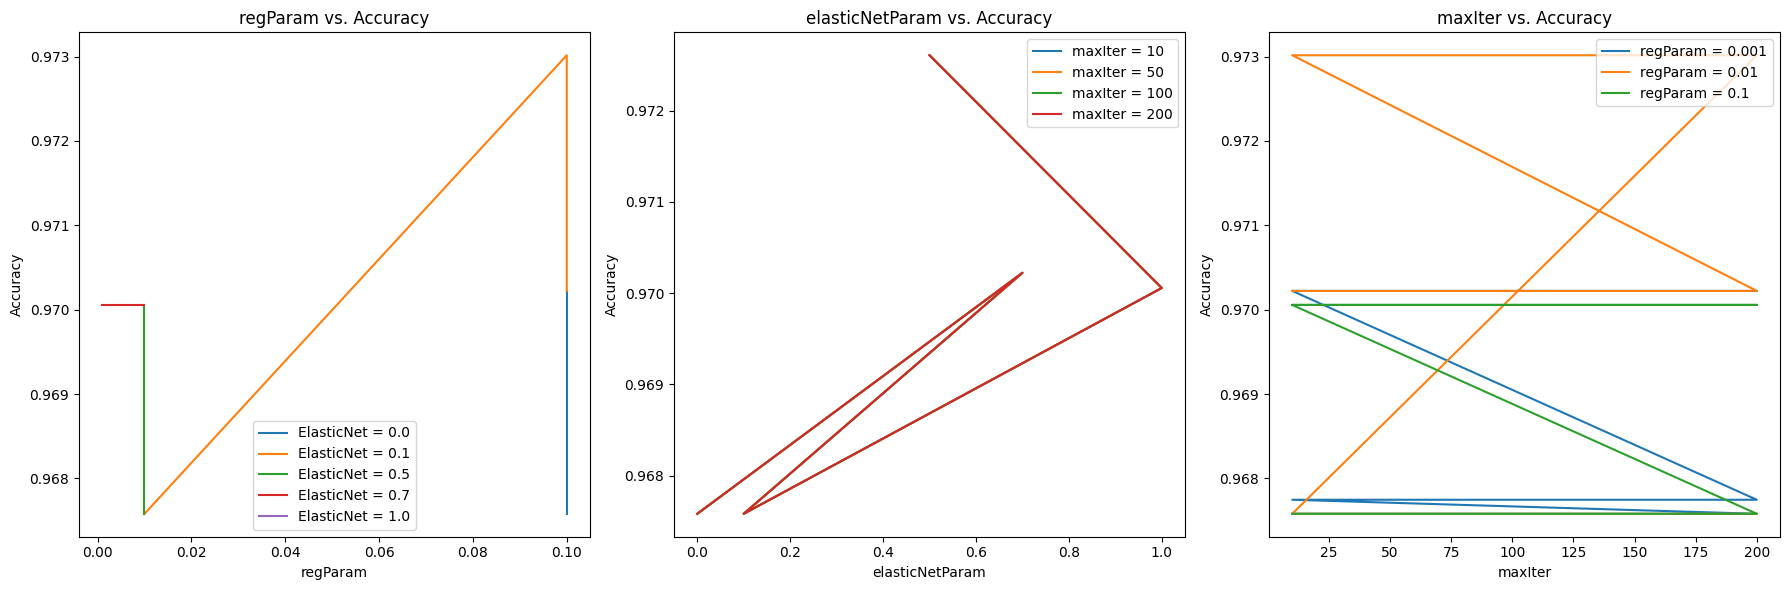

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Extracting cross-validation results
cv_rlts = cv_model_lr.avgMetrics

# Defining parameter grids
reglr_params = [params[lr.regParam] for params in parameter_grid]
elastic_net_params = [params[lr.elasticNetParam] for params in parameter_grid]
max_iters = [params[lr.maxIter] for params in parameter_grid]

# Reshaping results for plotting
reglr_params = np.array(reglr_params).reshape(len(np.unique(elastic_net_params)), -1)
elastic_net_params = np.array(elastic_net_params).reshape(len(np.unique(elastic_net_params)), -1)
max_iters = np.array(max_iters).reshape(len(np.unique(elastic_net_params)), -1)
cv_results = np.array(cv_rlts).reshape(len(np.unique(elastic_net_params)), -1)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot for reglr_params vs. Accuracy
for i, enet in enumerate(np.unique(elastic_net_params)):
    axs[0].plot(reglr_params[i], cv_results[i], label=f'ElasticNet = {enet}')
axs[0].set_xlabel('regParam')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('regParam vs. Accuracy')
axs[0].legend()

# Plot for elasticNetParam vs. Accuracy
for i, max_iter in enumerate(np.unique(max_iters)):
    axs[1].plot(elastic_net_params[:, i], cv_results[:, i], label=f'maxIter = {max_iter}')
axs[1].set_xlabel('elasticNetParam')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('elasticNetParam vs. Accuracy')
axs[1].legend()

# Plot for maxIter vs. Accuracy
for i, reg in enumerate(np.unique(reglr_params)):
    axs[2].plot(max_iters[i], cv_results[i], label=f'regParam = {reg}')
axs[2].set_xlabel('maxIter')
axs[2].set_ylabel('Accuracy')
axs[2].set_title('maxIter vs. Accuracy')
axs[2].legend()

plt.tight_layout()
plt.show()


**Bar Plot for Categorical Features**

<ipython-input-66-ade689079bc3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=accident_df_pd, x='Road_Type', palette='Set2')


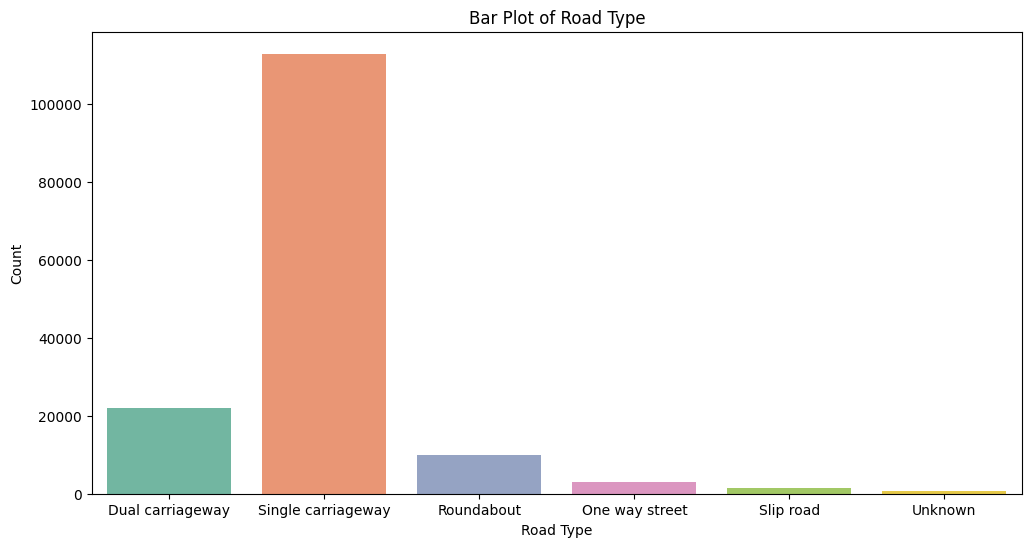

In [66]:
# Bar Plot for Categorical Features
plt.figure(figsize=(12, 6))
sns.countplot(data=accident_df_pd, x='Road_Type', palette='Set2')
plt.title('Bar Plot of Road Type')
plt.xlabel('Road Type')
plt.ylabel('Count')
plt.show()

**Plotting heatmap for the model results**

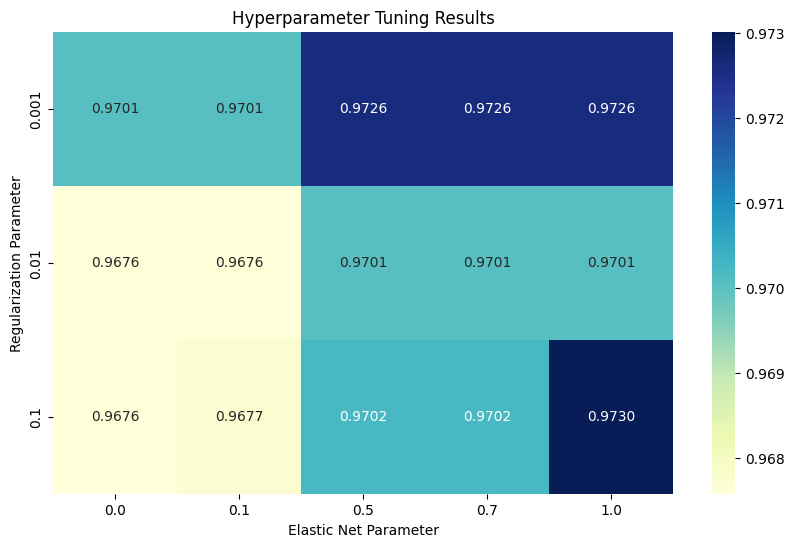

In [68]:
import pandas as pd
import seaborn as sns

# Extracting hyperparameters and corresponding evaluation metrics
parameters_val = cv_model_lr.getEstimatorParamMaps()
average_metrics = cv_model_lr.avgMetrics

# Converting param grid to dict for easier indexing
prm_dict = [{param.name: value for param, value in param_grid.items()} for param_grid in parameters_val]

# Creating a DataFrame to store hyperparameters and corresponding metrics
final_df = pd.DataFrame(prm_dict)
final_df['Avg Metric'] = average_metrics

# Reshaping the DataFrame to create a grid
heatmap_data = final_df.pivot_table(values='Avg Metric', index='regParam', columns='elasticNetParam')

# Creating the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('Hyperparameter Tuning Results')
plt.xlabel('Elastic Net Parameter')
plt.ylabel('Regularization Parameter')
plt.show()


---
# **Task 6 - LSEP Considerations (5 marks)**
---

In developing our Machine Learning model for analyzing UK road accident datasets, we have emphasized the fundamental principles of Legal (L), Social-Economic (S), and Ethical and Professional (E/P) considerations, often abbreviated as LSEP.

In terms of legal compliance, we have taken meticulous steps to adhere to data protection laws and regulations, prioritizing the protection of individuals' privacy who are involved in accidents.

Concerning social & economic impacts, we have conducted thorough assessments to understand how our model might affect diverse communities, striving to mitigate any potential negative repercussions on society or the economy.

Moreover, our approach has been guided by ethical and professional standards. We have prioritized transparency throughout our process, openly sharing our methodologies and outcomes to ensure fairness and impartiality for all stakeholders involved.

# Student 1: Kruttika Jamalpuram - **Legal Considerations:**

Creating a machine learning model for UK road accidents involves key legal considerations regarding data privacy, risk assessment, and regulatory compliance:

  

*   *Data Privacy and Security:* We ensure compliance with GDPR by anonymizing
    or pseudonymizing personal data in our datasets to protect individuals' privacy.

*   *Liability and Bias*: We carefully analyze the legal implications of using
    Machine Learning to assess fault in road accidents, taking into account potential biases that could impact liability assessments.

*   *Regulatory Compliance:* Our data collection and processing practices
    strictly adhere to relevant laws. The model's predictions and decisions align with the legislative frameworks governing road accidents.

*   *Legal Proceedings:* After an accident, legal actions may include personal
    injury claims covering medical expenses, loss of income, and pain and suffering. Additionally, property damage claims may arise. Serious cases involving reckless driving or criminal conduct may result in criminal charges.


# Student 2: Aishwarya Nitin Sonar - **Social-Economical Considerations:**

Considering the broader social and economic impacts of road accidents that affect various facets of society, including public health, safety, economic costs, and societal well-being, can be valuable for machine learning analysis:



*   *Public Health and Safety:* We have explored how our machine learning model's insights can contribute to improving road safety and reducing accidents, thereby positively influencing public health and safety and overall well-being.

*   *Economic Implications:* Machine Learning offers opportunities to identify cost-effective strategies for accident prevention and streamline insurance claim processing. It also aids in understanding the economic ramifications associated with road accidents.

*   *Equity and Access:* Our model takes into account disparities in road safety across different socioeconomic groups and geographic regions, aiming to address inequities and improve access to safe transportation.

*   *Insurance Premiums:* In the UK, high car insurance costs are often attributed to frequent accidents and associated expenses. Insurance providers calculate premiums based on accident likelihood and claims costs. Therefore, initiatives focused on road safety and accident prevention can potentially reduce insurance expenses for individuals and businesses.



# Student 3: Purvi Dawda - **Ethical/Professional Considerations**


Road accidents in the United Kingdom are governed by several ethical and professional considerations, including those relating to the roles of individuals, businesses, and organizations involved in road safety accident response and court proceedings. These considerations include upholding ethical principles, ensuring professional conduct and prioritizing the welfare of those affected by road accidents. Here is a closer look at these topics:


*  *Transparency and Explainability:* In accident investigations and court cases, ethical considerations call for accountability and transparency by the professionals involved in accident response and monitoring. They should act with integrity, provide accurate information to stakeholders, and take responsibility for their actions. This requires timely reporting of events and communicating information to the affected parties.

*  *Fairness and justice:* In the event of road accidents, fairness and justice are at the heart of good administration. One of the objectives is to ensure that accident victims are treated with respect, an adequate investigation into accidents and equitable allocation of resources and aid. Legal proceedings and insurance claims should be handled transparently and by ethical principles.

*  *Professional conduct:* We have ensured professional standards are met in data collection, model development, and decision-making. We have also considered the ethical implications of using technology in difficult fields such as accident investigation.

*  *Continuous improvement:* We understand that ethical and professional considerations contribute to improving road safety policies and accident response procedures continuously. Policymakers should learn from experience, implement best practices, and rewrite policies based on feedback and evaluation. To sustainably implement the proposed changes in the program, stakeholders should come forward and act together ethically and with integrity.




By carefully considering the legal, social-economic, ethical, and professional aspects of our project, we improved the accuracy of our machine learning algorithms. We ensured adherence to legal guidelines and rules, contemplated the effects on the economy, and maintained moral principles. By doing so, we were able to develop a more reliable and effective model for our project. Our commitment to these considerations has led to better outcomes and increased trust in our work.

# **Conclusion**

We have implemented three machine learning algorithms, namely Support Vector Machine (Linear SVC), Random Forest Classifier, and Linear Regression, on the UK Accidents dataset. We achieved high accuracy in predicting the severity of accidents using the features Road_Surface_Conditions and Weather_Conditions, with scores of 96%, 95%, and 95%, respectively.

---

# **Task 7 - Convert ipynb to HTML for Turnitin submission [5 marks]**

---



In [69]:
# install nbconvert (if facing the conversion error)
!pip3 install nbconvert

In [70]:
# convert ipynb to html and submit this HTML file
!jupyter nbconvert --to html Grp3_CRWK_UKAccidents.ipynb

[NbConvertApp] WARNING | pattern 'Grp3_CRWK_UKAccidents.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--e